## 2.Equality Assessment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load datasets
msoa_population_data = pd.read_csv('msoa-data.csv', encoding='ISO-8859-1')
msoa_stop_data = pd.read_csv('MSOA_nighttime_stops.csv')

In [3]:
# Merge datasets
merged_data = msoa_population_data.merge(msoa_stop_data, left_on="Middle Super Output Area", right_on="MSOA11CD", how="left")

In [4]:
# Calculate stop density (number of stops per thousand people)选择all ages列
merged_data["stop_density"] = merged_data["NUMPOINTS"] / merged_data["Age Structure (2011 Census);All Ages;"] * 1000

In [5]:
# Fill missing values in stop_density with 0
merged_data["stop_density"].fillna(0, inplace=True)

In [6]:
# Sort the data by stop_density and reset index
sorted_data = merged_data.sort_values(by="stop_density").reset_index(drop=True)

In [7]:
# Calculate Lorenz curve accumulations
n = len(sorted_data)
lorenz_curve_population = np.cumsum(np.ones(n) / n)
lorenz_curve_density = np.cumsum(sorted_data["stop_density"]) / sorted_data["stop_density"].sum()

In [8]:
# Calculate the area under the Lorenz curve
lorenz_area = np.trapz(lorenz_curve_density, lorenz_curve_population)

In [9]:
# Calculate Gini coefficient
gini_coefficient = 1 - 2 * lorenz_area

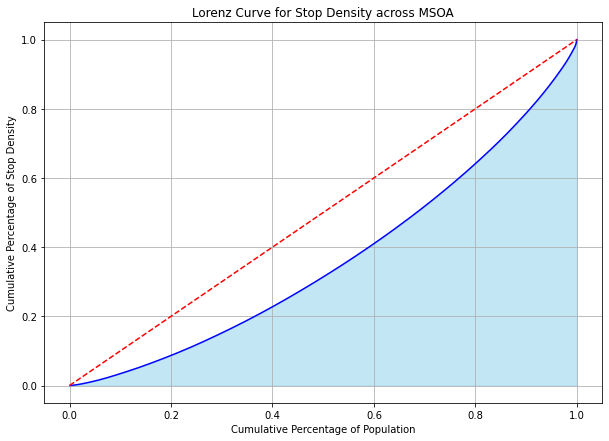

In [10]:
# Plotting the Lorenz curve
plt.figure(figsize=(10, 7))
plt.plot(lorenz_curve_population, lorenz_curve_density, label="Lorenz Curve", color='blue')
plt.plot([0,1], [0,1], linestyle="--", color='red', label="Line of Equality")
plt.fill_between(lorenz_curve_population, 0, lorenz_curve_density, color='skyblue', alpha=0.5)
plt.title("Lorenz Curve for Stop Density across MSOA")
plt.xlabel("Cumulative Percentage of Population")
plt.ylabel("Cumulative Percentage of Stop Density")
plt.grid(True)

In [11]:
print(gini_coefficient)

0.2711710500382668
